## Tarea 7: RNN — Soluciones (parte práctica)

Soluciones de los ejercicios de Python de la tarea de práctica. La numeración corresponde a la versión actual de `tareas/Tarea7.ipynb`. Úsalas para verificar tu trabajo (o el de tu agente) **después** de intentarlo.

### Nota sobre el corpus: por qué nos desviamos del notebook de clase

El notebook de clase (`notebooks/NotebookRNN.ipynb`) usa como corpus un **fragmento inline del Quijote de 66 palabras**.
Ese texto es perfecto para lo que hace el notebook de clase — mostrar el mecanismo de tokenización, `NextWordDataset` y el
bucle de entrenamiento — pero es **inservible para el experimento que pide esta tarea**:

1. Con 66 palabras y `seq_len ≈ 20` quedan ~46 ejemplos. Un split 90/10 deja ~5 ejemplos de validación: la `val_perplexity`
   sería puro ruido de muestreo y no permitiría **comparar arquitecturas**, que es el objetivo.
2. Con `batch_size = 128` habría **un solo batch por época**: SGD y Adam serían indistinguibles porque nunca se ejerce
   la dinámica de mini-batch que los diferencia.
3. Con casi todo el vocabulario apareciendo una sola vez, `min_freq = 2` vaciaría el vocabulario.
4. Lo más importante: las tres células (RNN, LSTM, GRU) memorizarían el corpus completo en pocas épocas. La pregunta de la
   tarea — *cuál generaliza mejor* — no tendría respuesta observable, porque no habría nada que generalizar.

**Qué hacemos en su lugar.** Mantenemos *toda* la maquinaria del notebook de clase (mismo `tokenize`, mismo `build_vocab`,
mismo `NextWordDataset`, mismo split, mismo `train_loop` con gradient clipping) y sólo **cambiamos el corpus**: descargamos
el Quijote completo en español desde Project Gutenberg, quitamos la cabecera/pie de licencia y nos quedamos con las
**primeras 50 000 palabras** (Parte I, desde el "Capítulo primero"). El texto queda **cacheado en `soluciones/data/quijote.txt`**;
el notebook sólo descarga si el caché no existe, así que las re-ejecuciones son offline y reproducibles.

Esto nos da ~57 000 tokens y ~3 000 palabras de vocabulario: suficiente para que las diferencias entre células recurrentes
sean señal y no ruido, y lo bastante pequeño para que las 9 corridas quepan en minutos sobre la GPU de un portátil.

In [1]:
# ---------------------------
# Imports & utilidades básicas (idénticas al notebook de clase)
# ---------------------------
import re
import os
import math
import time
import random
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, Subset


# ---------------------------
# Reproducibilidad y dispositivo
# ---------------------------
def set_seed(seed=1234):
    """Fija semillas para reproducibilidad (random, numpy y torch)."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def find_device():
    """Detecta el mejor device disponible: CUDA > MPS (Apple) > CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def sync(device):
    """
    Sincroniza la cola asíncrona del acelerador.

    CUDA y MPS ejecutan los kernels de forma asíncrona: sin esta llamada,
    `time.time()` mediría cuándo se *encoló* el trabajo, no cuándo terminó,
    y los tiempos por época que reportamos serían basura.
    """
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()


# ---------------------------
# Parámetros globales del experimento (los que pide la tarea)
# ---------------------------
SEED = 1234
DEVICE = find_device()
set_seed(SEED)

SEQ_LEN     = 20      # ventana de contexto (next-word)
EMBED_DIM   = 128     # idéntico en las 3 arquitecturas
HIDDEN_SIZE = 256     # lo pide la tarea
NUM_LAYERS  = 1       # lo pide la tarea
DROPOUT     = 0.0     # lo pide la tarea
CLIP        = 1.0     # gradient clipping, igual que en el train_loop de clase
VAL_FRAC    = 0.1     # split 90/10

EPOCHS_FULL = 30
BATCH_FULL  = 128

TRAIN_SIZE_SMALL = 2000
EPOCHS_SMALL     = 40
BATCH_SMALL      = 64

print("DEVICE:", DEVICE)
print("torch:", torch.__version__)
print("SEED:", SEED)

DEVICE: mps
torch: 2.11.0
SEED: 1234


#### 1. Corpus: descarga y caché

`load_quijote()` implementa la política de caché: si `soluciones/data/quijote.txt` existe lo lee y no toca la red;
si no existe, descarga de Project Gutenberg, recorta cabecera/pie y guarda el caché.

In [2]:
# ---------------------------
# Corpus: Quijote completo (Project Gutenberg) con caché local
# ---------------------------
GUTENBERG_URL = "https://www.gutenberg.org/cache/epub/2000/pg2000.txt"
CACHE_PATH    = os.path.join("data", "quijote.txt")   # relativo a soluciones/
N_WORDS       = 50_000                                # ~50k palabras (rango pedido: 40k-60k)


def load_quijote(cache_path=CACHE_PATH, n_words=N_WORDS, url=GUTENBERG_URL):
    """
    Devuelve las primeras `n_words` palabras del Quijote en español.

    - Si `cache_path` existe: lo lee (offline, reproducible).
    - Si no: descarga de Gutenberg, elimina la cabecera/pie de licencia,
      arranca en el "Capítulo primero" (salta portada, tasa, prólogo y versos
      preliminares, que son texto de otro registro y ensuciarían el vocabulario),
      recorta a n_words y escribe el caché.
    """
    if os.path.exists(cache_path):
        with open(cache_path, encoding="utf-8") as f:
            txt = f.read()
        print(f"Corpus leído del caché: {cache_path}")
        return txt

    print(f"Caché no encontrado; descargando de {url} ...")
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=180) as resp:
        raw = resp.read().decode("utf-8", errors="replace")

    # 1) quitar cabecera y pie de Project Gutenberg
    i = raw.find("*** START OF THE PROJECT GUTENBERG EBOOK")
    j = raw.find("*** END OF THE PROJECT GUTENBERG EBOOK")
    body = raw[raw.find("\n", i) + 1 : j] if (i != -1 and j != -1) else raw

    # 2) arrancar en la primera línea de la novela propiamente dicha
    k = body.find("En un lugar de la Mancha")
    if k != -1:
        body = body[k:]

    # 3) recortar a n_words y normalizar espacios en blanco
    txt = " ".join(body.split()[:n_words])

    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    with open(cache_path, "w", encoding="utf-8") as f:
        f.write(txt)
    print(f"Caché escrito en {cache_path}")
    return txt


text = load_quijote()
print("Caracteres total:", len(text))
print("Palabras (split simple):", len(text.split()))
print("\nPrimeros 300 caracteres:\n", text[:300])

Corpus leído del caché: data/quijote.txt
Caracteres total: 273283
Palabras (split simple): 50000

Primeros 300 caracteres:
 En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua, rocín flaco y galgo corredor. Una olla de algo más vaca que carnero, salpicón las más noches, duelos y quebrantos los sábados, lantejas los viernes, alg


#### 2. Tokenización y vocabulario

`tokenize` y `build_vocab` son **copia literal del notebook de clase**. Lo único que cambia es `min_freq=2`
(lo pide el enunciado): las palabras que aparecen una sola vez colapsan a `<unk>`. Esto reduce el vocabulario
casi a la mitad, lo que a su vez baja el costo del `softmax` de salida — que es la capa más cara del modelo.

In [3]:
# ---------------------------
# Tokenización simple (idéntica al notebook de clase)
# ---------------------------
def tokenize(text):
    """
    Tokenizador muy sencillo:
    - case-folding a minúsculas (reduce sparsity)
    - saltos de línea -> espacio
    - separa signos de puntuación (.,;:!?()") como tokens independientes
    - colapsa espacios múltiples y hace split
    """
    text = text.lower()
    text = text.replace('\n', ' ')
    text = re.sub(r'([.,;:!?()\"])', r' \1 ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text.split(' ')


# ---------------------------
# Construcción del vocabulario (idéntica al notebook de clase)
# ---------------------------
def build_vocab(tokens, min_freq=1, reserved_tokens=['<pad>', '<unk>']):
    """
    Construye vocabulario a partir de una lista de tokens.
    Retorna (itos, stoi, counter).
    """
    counter = Counter(tokens)
    words = [w for w, c in counter.items() if c >= min_freq]
    words.sort(key=lambda w: (-counter[w], w))          # frecuencia desc., lexicográfico como desempate
    itos = list(reserved_tokens) + words
    stoi = {w: i for i, w in enumerate(itos)}
    return itos, stoi, counter


tokens = tokenize(text)
itos, stoi, counter = build_vocab(tokens, min_freq=2)   # min_freq=2 como pide la tarea
vocab_size = len(itos)

n_types = len(counter)
n_unk_types = n_types - (vocab_size - 2)
n_unk_tokens = sum(c for w, c in counter.items() if c < 2)

print('Número de tokens:', len(tokens))
print('Tipos (palabras distintas):', n_types)
print('Vocab size (min_freq=2):', vocab_size)
print(f'Tipos mapeados a <unk>: {n_unk_types}  ({n_unk_tokens} tokens = {100*n_unk_tokens/len(tokens):.1f}% del corpus)')
print('Primeros 20 tokens del vocab:', itos[:20])

Número de tokens: 57404
Tipos (palabras distintas): 7093
Vocab size (min_freq=2): 2973
Tipos mapeados a <unk>: 4122  (4122 tokens = 7.2% del corpus)
Primeros 20 tokens del vocab: ['<pad>', '<unk>', ',', 'que', 'de', 'y', 'la', 'a', '.', 'el', 'en', 'no', ';', 'se', 'los', 'con', 'su', 'por', 'le', 'las']


#### 3. Dataset y loaders

`NextWordDataset` es el del notebook de clase. `make_loaders` también, con dos cambios menores:
`val_frac=0.1` (split 90/10 que pide la tarea) y un parámetro opcional `train_size` para el experimento de
datos limitados. **El split se calcula una sola vez con `seed=1234`**, así que las 9 corridas ven exactamente
los mismos ejemplos en train y en val — sin eso, la comparación entre arquitecturas no sería válida.

In [4]:
# ---------------------------
# Dataset next-token (idéntico al notebook de clase)
# ---------------------------
class NextWordDataset(Dataset):
    """
    Dataset para predicción de la *siguiente palabra*.
    Cada ejemplo: X = seq_len ids de contexto, y = id del token siguiente.
    """
    def __init__(self, tokens, stoi, seq_len=5):
        self.seq_len = seq_len
        self.stoi = stoi
        self.tokens = tokens
        self.vocab_size = len(stoi)

        unk_idx = self.stoi.get('<unk>')
        self.ids = [self.stoi.get(t, unk_idx) for t in tokens]
        self.n = max(0, len(self.ids) - seq_len)

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        x = torch.tensor(self.ids[idx:idx + self.seq_len], dtype=torch.long)
        y = torch.tensor(self.ids[idx + self.seq_len], dtype=torch.long)
        return x, y

    def decode_example(self, idx):
        """Devuelve (tokens_contexto, token_objetivo) legible para el ejemplo idx."""
        if idx < 0 or idx >= self.n:
            raise IndexError("idx fuera de rango")
        ctx_ids = self.ids[idx:idx + self.seq_len]
        tgt_id = self.ids[idx + self.seq_len]
        inv = {i: w for w, i in self.stoi.items()}
        return [inv.get(i, '<unk>') for i in ctx_ids], inv.get(tgt_id, '<unk>')


# ---------------------------
# Loaders con split reproducible 90/10
# ---------------------------
def make_loaders(tokens, stoi, seq_len=SEQ_LEN, batch_size=128,
                 val_frac=VAL_FRAC, seed=SEED, train_size=None):
    """
    Crea DataLoaders train/val.
    - El split se decide con `seed` fijo => idéntico en todas las corridas.
    - `train_size`: si se indica, submuestrea el train a ese número de ejemplos
      (para la demo de datos limitados). La validación NO se toca, así las
      perplexities siguen siendo comparables entre el experimento completo y el small-data.
    """
    dataset = NextWordDataset(tokens, stoi, seq_len=seq_len)
    N = len(dataset)
    if N == 0:
        raise ValueError('Dataset vacío: reduce seq_len o usa más texto.')

    rng = np.random.RandomState(seed)
    idx = np.arange(N)
    rng.shuffle(idx)

    n_val = max(1, int(val_frac * N))
    val_idx = idx[:n_val]
    train_idx = idx[n_val:]

    if train_size is not None:
        train_idx = train_idx[:train_size]

    train_ds = Subset(dataset, train_idx)
    val_ds = Subset(dataset, val_idx)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


full_ds = NextWordDataset(tokens, stoi, seq_len=SEQ_LEN)
print('Ejemplos totales (seq_len=%d): %d' % (SEQ_LEN, len(full_ds)))

ctx, tgt = full_ds.decode_example(0)
print('\nEjemplo 0:')
print('  contexto:', ' '.join(ctx))
print('  objetivo :', tgt)

train_loader, val_loader = make_loaders(tokens, stoi, seq_len=SEQ_LEN, batch_size=BATCH_FULL)
print('\nTrain: %d ejemplos (%d batches) | Val: %d ejemplos (%d batches)'
      % (len(train_loader.dataset), len(train_loader), len(val_loader.dataset), len(val_loader)))

Ejemplos totales (seq_len=20): 57384

Ejemplo 0:
  contexto: en un lugar de la mancha , de cuyo nombre no quiero <unk> , no ha mucho tiempo que vivía
  objetivo : un

Train: 51646 ejemplos (404 batches) | Val: 5738 ejemplos (45 batches)


#### 4. Modelo: una sola clase, tres células

`RecurrentLM` es el `SimpleRNNLM` de clase generalizado con un parámetro `cell_type`. La arquitectura es
**idéntica en los tres casos** — `Embedding(V, 128) → recurrente(128→256) → Linear(256, V)`, tomando la última
salida temporal — y lo único que cambia es qué módulo de PyTorch ocupa el lugar de la recurrencia.

**Sobre la inicialización.** La tarea pide "la misma semilla y la misma función de inicialización". Hay una sutileza:
`nn.RNN`, `nn.LSTM` y `nn.GRU` consumen un número *distinto* de números aleatorios (LSTM tiene 4 matrices de puertas,
GRU 3, RNN 1), así que basta con que exista la célula para que el generador quede desfasado. Para que la comparación sea
lo más limpia posible, `build_model`:

1. re-siembra con `SEED` **antes** de construir el modelo → la `Embedding` (primer módulo creado) sale **bit a bit idéntica**
   en las tres arquitecturas;
2. re-siembra otra vez y reinicializa el `Linear` de salida con `reset_parameters()` → la capa de salida también es idéntica;
3. las matrices recurrentes no pueden ser idénticas (tienen formas distintas), pero **sí salen de la misma distribución**:
   PyTorch inicializa las tres células con `U(-1/√hidden, 1/√hidden)`, y al re-sembrar antes de construir, las tres parten
   del mismo estado del generador.

Es la definición más fuerte de "misma inicialización" que admite una comparación entre células distintas.

In [5]:
# ---------------------------
# Modelo: embedding -> célula recurrente -> linear (vocab)
# ---------------------------
CELLS = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}


class RecurrentLM(nn.Module):
    """
    Modelo de lenguaje next-token. Generalización de SimpleRNNLM del notebook de clase:
    la única diferencia entre configuraciones es `cell_type` in {'RNN','LSTM','GRU'}.
    """
    def __init__(self, vocab_size, cell_type='RNN', embed_dim=EMBED_DIM,
                 hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS, dropout=DROPOUT):
        super().__init__()
        if cell_type not in CELLS:
            raise ValueError(f"cell_type debe ser uno de {list(CELLS)}, recibí {cell_type!r}")

        self.cell_type = cell_type
        self.embed = nn.Embedding(vocab_size, embed_dim)

        kwargs = dict(input_size=embed_dim,
                      hidden_size=hidden_size,
                      num_layers=num_layers,
                      batch_first=True,
                      dropout=dropout if num_layers > 1 else 0.0)
        if cell_type == 'RNN':
            kwargs['nonlinearity'] = 'tanh'      # sólo nn.RNN acepta este argumento
        self.rnn = CELLS[cell_type](**kwargs)

        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        """x: (B, T) LongTensor -> logits (B, V) del token siguiente."""
        emb = self.embed(x)          # (B, T, embed_dim)
        out, _ = self.rnn(emb)       # out: (B, T, hidden)   (LSTM devuelve (h,c); lo ignoramos igual)
        last = out[:, -1, :]         # (B, hidden) — última salida temporal
        return self.fc(last)         # (B, vocab_size)


def count_params(model):
    """Cuenta parámetros entrenables."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def build_model(cell_type, vocab_size=vocab_size, seed=SEED):
    """
    Construye el modelo con inicialización lo más controlada posible entre células
    (ver la nota de markdown de arriba).
    """
    set_seed(seed)
    model = RecurrentLM(vocab_size, cell_type=cell_type)
    set_seed(seed)
    model.fc.reset_parameters()     # capa de salida idéntica en las 3 arquitecturas
    return model


# Verificación: la embedding debe ser idéntica en las tres arquitecturas
m_rnn, m_lstm, m_gru = build_model('RNN'), build_model('LSTM'), build_model('GRU')
print("Embedding idéntica RNN vs LSTM:", torch.equal(m_rnn.embed.weight, m_lstm.embed.weight))
print("Embedding idéntica RNN vs GRU :", torch.equal(m_rnn.embed.weight, m_gru.embed.weight))
print("Linear salida idéntico RNN vs LSTM:", torch.equal(m_rnn.fc.weight, m_lstm.fc.weight))

print("\nParámetros entrenables (vocab_size = %d):" % vocab_size)
for name, m in [('RNN', m_rnn), ('LSTM', m_lstm), ('GRU', m_gru)]:
    rec = sum(p.numel() for p in m.rnn.parameters())
    print(f"  {name:5s}: total {count_params(m):>9,}  | sólo la célula recurrente: {rec:>8,}")

del m_rnn, m_lstm, m_gru

Embedding idéntica RNN vs LSTM: True
Embedding idéntica RNN vs GRU : True
Linear salida idéntico RNN vs LSTM: True

Parámetros entrenables (vocab_size = 2973):
  RNN  : total 1,243,421  | sólo la célula recurrente:   98,816
  LSTM : total 1,539,869  | sólo la célula recurrente:  395,264
  GRU  : total 1,441,053  | sólo la célula recurrente:  296,448


#### 5. Evaluación y bucle de entrenamiento

`evaluate` es el del notebook de clase. `train_loop` también, con tres añadidos que la tarea exige:

- recibe el **optimizador ya construido** (para poder pasar exactamente `SGD(lr=1e-2, momentum=0.9, weight_decay=0)`
  y `Adam(lr=1e-3, weight_decay=0)`);
- **cronometra cada época** — separando el tiempo de *entrenamiento* del tiempo de *evaluación*, porque lo que
  compara arquitecturas es el costo de entrenar, no el de medir;
- conserva el **gradient clipping** (`clip_grad_norm_(..., 1.0)`), imprescindible en la RNN vanilla.

In [6]:
# ---------------------------
# Evaluación: pérdida promedio, perplexity y accuracy (idéntica al notebook de clase)
# ---------------------------
def evaluate(model, loader, device):
    """
    Retorna (loss_avg, perplexity, accuracy) del modelo sobre `loader`.
    perplexity = exp(cross-entropy promedio).
    """
    model.eval()
    loss_fn = nn.CrossEntropyLoss()

    total_loss = 0.0
    total_examples = 0
    correct = 0

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            total_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=-1) == yb).sum().item()
            total_examples += xb.size(0)

    if total_examples == 0:
        return float('nan'), float('nan'), float('nan')

    loss_avg = total_loss / total_examples
    try:
        perp = math.exp(loss_avg)
    except OverflowError:
        perp = float('inf')
    return loss_avg, perp, correct / total_examples


# ---------------------------
# Bucle de entrenamiento con cronometraje
# ---------------------------
def train_loop(model, train_loader, val_loader, device, optimizer,
               epochs=10, clip=CLIP, log_every=5, tag=''):
    """
    Entrena y registra por época: train/val loss, perplexity, accuracy y tiempo.

    `epoch_time` mide SÓLO el paso de entrenamiento (forward+backward+step de todos
    los batches), sincronizando el acelerador antes de parar el cronómetro.
    El tiempo de evaluación se registra aparte y no contamina la comparación.
    """
    model = model.to(device)
    loss_fn = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [],
               'train_perp': [], 'val_perp': [],
               'train_acc': [], 'val_acc': [],
               'epoch_time': [], 'eval_time': []}

    t_wall = time.time()

    for ep in range(1, epochs + 1):
        model.train()
        sync(device)
        t0 = time.time()

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            # clipping de gradiente: evita exploding gradients en RNNs
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
            optimizer.step()

        sync(device)
        epoch_time = time.time() - t0

        # evaluación completa al final de la época (fuera del cronómetro de entrenamiento)
        t1 = time.time()
        train_loss, train_perp, train_acc = evaluate(model, train_loader, device)
        val_loss, val_perp, val_acc = evaluate(model, val_loader, device)
        sync(device)
        eval_time = time.time() - t1

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_perp'].append(train_perp)
        history['val_perp'].append(val_perp)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['epoch_time'].append(epoch_time)
        history['eval_time'].append(eval_time)

        if ep == 1 or ep == epochs or ep % log_every == 0:
            print(f'  {tag} epoch {ep:>2}/{epochs}  t={epoch_time:5.2f}s  '
                  f'train_perp={train_perp:8.2f}  val_perp={val_perp:8.2f}  val_acc={val_acc:.4f}')

    history['wall_time'] = time.time() - t_wall
    return history


def make_optimizer(name, model):
    """Los dos optimizadores exactos que pide la tarea."""
    if name == 'SGD':
        return torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=0.0)
    if name == 'Adam':
        return torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.0)
    raise ValueError(f"optimizador desconocido: {name!r}")


def run_experiment(cell_type, optim_name, train_loader, val_loader,
                   epochs, seed=SEED, tag=''):
    """
    Una corrida completa: re-siembra, construye modelo y optimizador, entrena.
    La re-siembra antes de entrenar fija también el orden de shuffle del DataLoader,
    así que dos corridas con la misma arquitectura ven los batches en el mismo orden.
    """
    set_seed(seed)
    model = build_model(cell_type, seed=seed)
    optimizer = make_optimizer(optim_name, model)
    set_seed(seed)   # fija el orden de los batches
    hist = train_loop(model, train_loader, val_loader, DEVICE, optimizer,
                      epochs=epochs, tag=tag)
    hist['cell'] = cell_type
    hist['optim'] = optim_name
    hist['n_params'] = count_params(model)
    return model, hist

---

## Experimento 1 — Dataset completo: 3 arquitecturas × 2 optimizadores

6 corridas, `epochs=30`, `batch_size=128`. Todo idéntico salvo (a) la célula recurrente y (b) el optimizador.

In [7]:
# ---------------------------
# 6 corridas: {RNN, LSTM, GRU} x {SGD, Adam}
# ---------------------------
ARCHS = ['RNN', 'LSTM', 'GRU']
OPTIMS = ['SGD', 'Adam']

histories = {}      # (cell, optim) -> history
models = {}         # (cell, optim) -> modelo entrenado (para muestrear al final)

t_all = time.time()
for optim_name in OPTIMS:
    for cell in ARCHS:
        key = (cell, optim_name)
        print(f"\n=== {cell} + {optim_name} | epochs={EPOCHS_FULL}, batch={BATCH_FULL} ===")
        model, hist = run_experiment(cell, optim_name, train_loader, val_loader,
                                     epochs=EPOCHS_FULL, tag=f'[{cell}/{optim_name}]')
        histories[key] = hist
        models[key] = model

print(f"\n>>> 6 corridas completadas en {(time.time()-t_all)/60:.1f} minutos.")


=== RNN + SGD | epochs=30, batch=128 ===


  [RNN/SGD] epoch  1/30  t= 3.09s  train_perp=  199.58  val_perp=  213.13  val_acc=0.1495


  [RNN/SGD] epoch  5/30  t= 2.27s  train_perp=  123.70  val_perp=  148.56  val_acc=0.1720


  [RNN/SGD] epoch 10/30  t= 2.28s  train_perp=   92.29  val_perp=  130.10  val_acc=0.1844


  [RNN/SGD] epoch 15/30  t= 2.51s  train_perp=   72.58  val_perp=  121.20  val_acc=0.1880


...

  [GRU/Adam] epoch 10/30  t= 4.03s  train_perp=    3.90  val_perp=  183.65  val_acc=0.1724


  [GRU/Adam] epoch 15/30  t= 4.15s  train_perp=    1.63  val_perp=  432.81  val_acc=0.1558


  [GRU/Adam] epoch 20/30  t= 4.29s  train_perp=    1.16  val_perp= 1217.39  val_acc=0.1424


  [GRU/Adam] epoch 25/30  t= 4.17s  train_perp=    1.05  val_perp= 2715.56  val_acc=0.1422


  [GRU/Adam] epoch 30/30  t= 3.80s  train_perp=    1.05  val_perp= 5400.67  val_acc=0.1394

>>> 6 corridas completadas en 12.8 minutos.


In [8]:
# ---------------------------
# Tabla resumen del experimento 1
# ---------------------------
rows = []
for (cell, opt), h in histories.items():
    best_ep = int(np.argmin(h['val_perp']))
    rows.append({
        'arquitectura': cell,
        'optimizador': opt,
        'params': h['n_params'],
        'train_loss_final': h['train_loss'][-1],
        'val_loss_final': h['val_loss'][-1],
        'train_perp_final': h['train_perp'][-1],
        'val_perp_final': h['val_perp'][-1],
        'val_perp_min': h['val_perp'][best_ep],
        'epoca_mejor_val': best_ep + 1,
        'val_acc_final': h['val_acc'][-1],
        'tiempo_medio_epoca_s': float(np.mean(h['epoch_time'])),
        'tiempo_total_entren_s': float(np.sum(h['epoch_time'])),
        'tiempo_wall_total_s': h['wall_time'],
    })

resumen = pd.DataFrame(rows).sort_values(['optimizador', 'val_perp_min']).reset_index(drop=True)

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
print("=== Experimento 1: dataset completo, epochs=%d, batch=%d ===\n" % (EPOCHS_FULL, BATCH_FULL))
print(resumen.round(3).to_string(index=False))

=== Experimento 1: dataset completo, epochs=30, batch=128 ===

arquitectura optimizador  params  train_loss_final  val_loss_final  train_perp_final  val_perp_final  val_perp_min  epoca_mejor_val  val_acc_final  tiempo_medio_epoca_s  tiempo_total_entren_s  tiempo_wall_total_s
         GRU        Adam 1441053             0.051           8.594             1.052        5400.665       103.811                4          0.139                 4.082                122.475              179.357
        LSTM        Adam 1539869             0.058           7.674             1.059        2151.364       103.899                5          0.142                 1.767                 53.003               86.731
         RNN        Adam 1243421             0.432           7.390             1.540        1618.911       115.472                4          0.146                 2.543                 76.304              124.992
         GRU         SGD 1441053             3.796           4.715            44.517 

In [9]:
# ---------------------------
# Tabla compacta: val_perplexity mínima y tiempo medio por época
# ---------------------------
piv_perp = resumen.pivot(index='arquitectura', columns='optimizador', values='val_perp_min').loc[ARCHS]
piv_time = resumen.pivot(index='arquitectura', columns='optimizador', values='tiempo_medio_epoca_s').loc[ARCHS]

print("val_perplexity MÍNIMA (menor es mejor)")
print(piv_perp.round(2).to_string())
print("\ntiempo medio por época (segundos)")
print(piv_time.round(2).to_string())

mejor = resumen.loc[resumen['val_perp_min'].idxmin()]
print(f"\nMejor corrida global: {mejor['arquitectura']} + {mejor['optimizador']}  "
      f"-> val_perp_min = {mejor['val_perp_min']:.2f} (época {int(mejor['epoca_mejor_val'])})")

val_perplexity MÍNIMA (menor es mejor)
optimizador     Adam     SGD
arquitectura                
RNN           115.47  118.69
LSTM          103.90  122.02
GRU           103.81  110.75

tiempo medio por época (segundos)
optimizador   Adam   SGD
arquitectura            
RNN           2.54  2.42
LSTM          1.77  1.60
GRU           4.08  3.56

Mejor corrida global: GRU + Adam  -> val_perp_min = 103.81 (época 4)


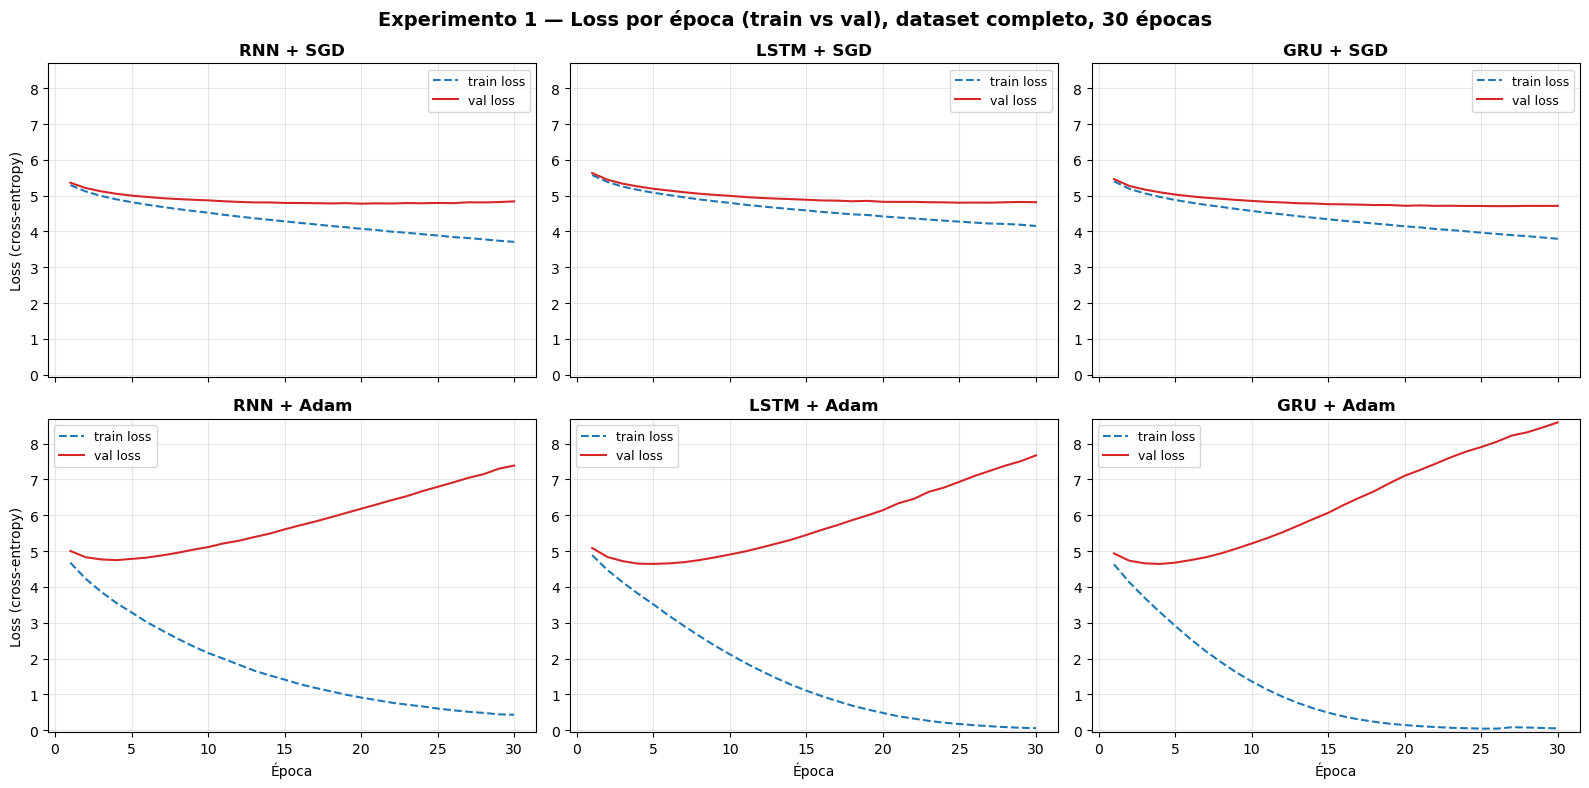

In [10]:
# ---------------------------
# Curvas de LOSS (train vs val) — una figura, un panel por corrida
# ---------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
colors = {'train': 'tab:blue', 'val': 'tab:red'}

for r, opt in enumerate(OPTIMS):
    for c, cell in enumerate(ARCHS):
        ax = axes[r, c]
        h = histories[(cell, opt)]
        ep = np.arange(1, len(h['train_loss']) + 1)
        ax.plot(ep, h['train_loss'], '--', color=colors['train'], label='train loss')
        ax.plot(ep, h['val_loss'], '-', color=colors['val'], label='val loss')
        ax.set_title(f'{cell} + {opt}', fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3)
        if r == 1:
            ax.set_xlabel('Época')
        if c == 0:
            ax.set_ylabel('Loss (cross-entropy)')
        ax.legend(fontsize=9)

# misma escala Y en toda la rejilla para que los paneles sean comparables a ojo
ymin = min(min(h['train_loss'] + h['val_loss']) for h in histories.values())
ymax = max(max(h['train_loss'] + h['val_loss']) for h in histories.values())
for ax in axes.ravel():
    ax.set_ylim(ymin - 0.1, ymax + 0.1)

fig.suptitle('Experimento 1 — Loss por época (train vs val), dataset completo, 30 épocas',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

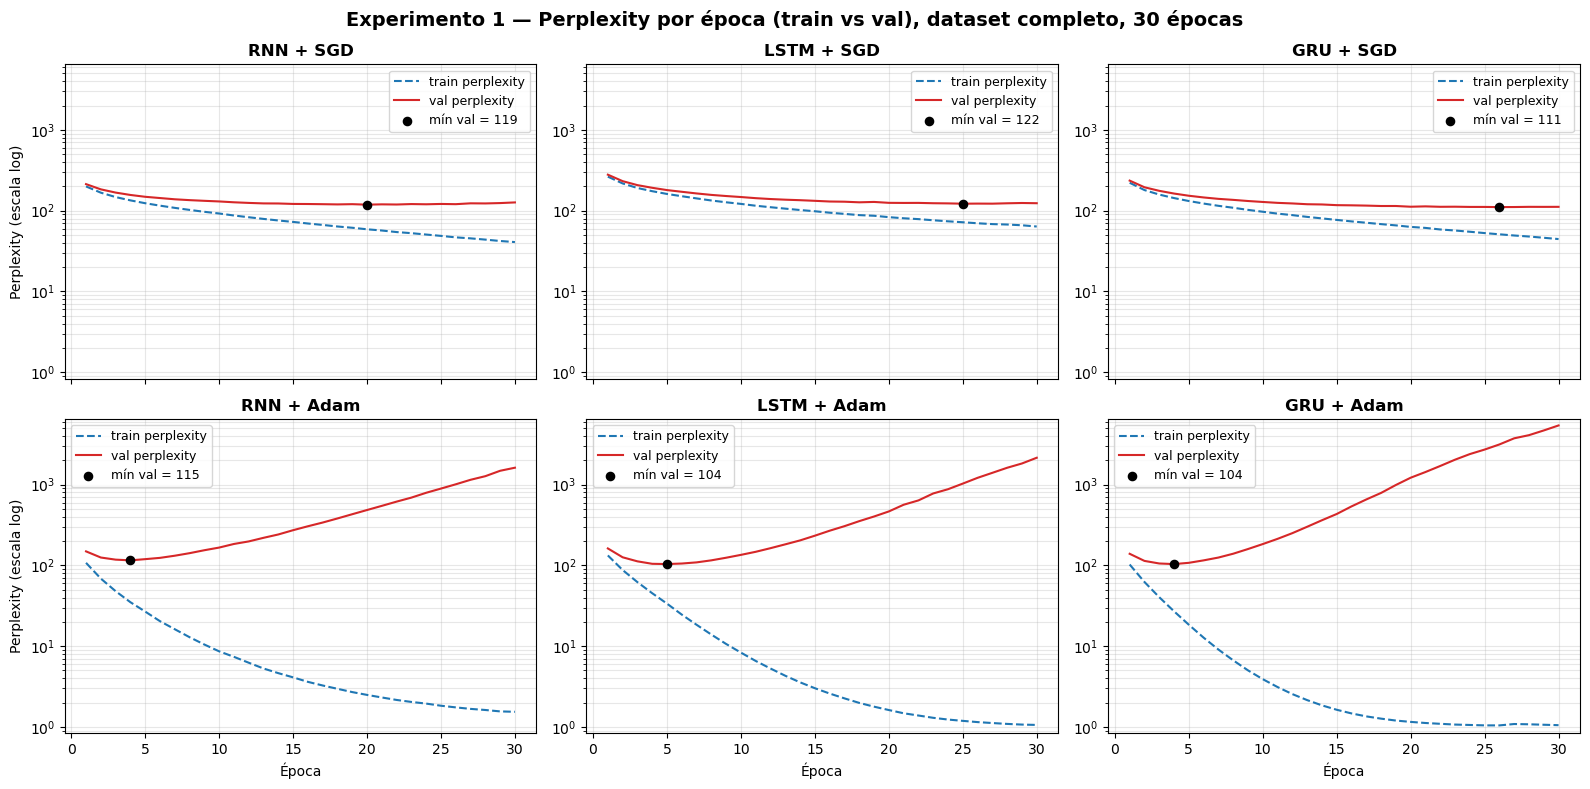

In [11]:
# ---------------------------
# Curvas de PERPLEXITY (train vs val) — figura separada, escala log
# ---------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)

for r, opt in enumerate(OPTIMS):
    for c, cell in enumerate(ARCHS):
        ax = axes[r, c]
        h = histories[(cell, opt)]
        ep = np.arange(1, len(h['train_perp']) + 1)
        ax.plot(ep, h['train_perp'], '--', color='tab:blue', label='train perplexity')
        ax.plot(ep, h['val_perp'], '-', color='tab:red', label='val perplexity')
        best = int(np.argmin(h['val_perp']))
        ax.scatter([best + 1], [h['val_perp'][best]], color='k', zorder=5, s=35,
                   label=f'mín val = {h["val_perp"][best]:.0f}')
        ax.set_yscale('log')
        ax.set_title(f'{cell} + {opt}', fontsize=12, fontweight='bold')
        ax.grid(True, which='both', alpha=0.3)
        if r == 1:
            ax.set_xlabel('Época')
        if c == 0:
            ax.set_ylabel('Perplexity (escala log)')
        ax.legend(fontsize=9)

pmin = min(min(h['train_perp'] + h['val_perp']) for h in histories.values())
pmax = max(max(h['train_perp'] + h['val_perp']) for h in histories.values())
for ax in axes.ravel():
    ax.set_ylim(pmin * 0.8, pmax * 1.2)

fig.suptitle('Experimento 1 — Perplexity por época (train vs val), dataset completo, 30 épocas',
             fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

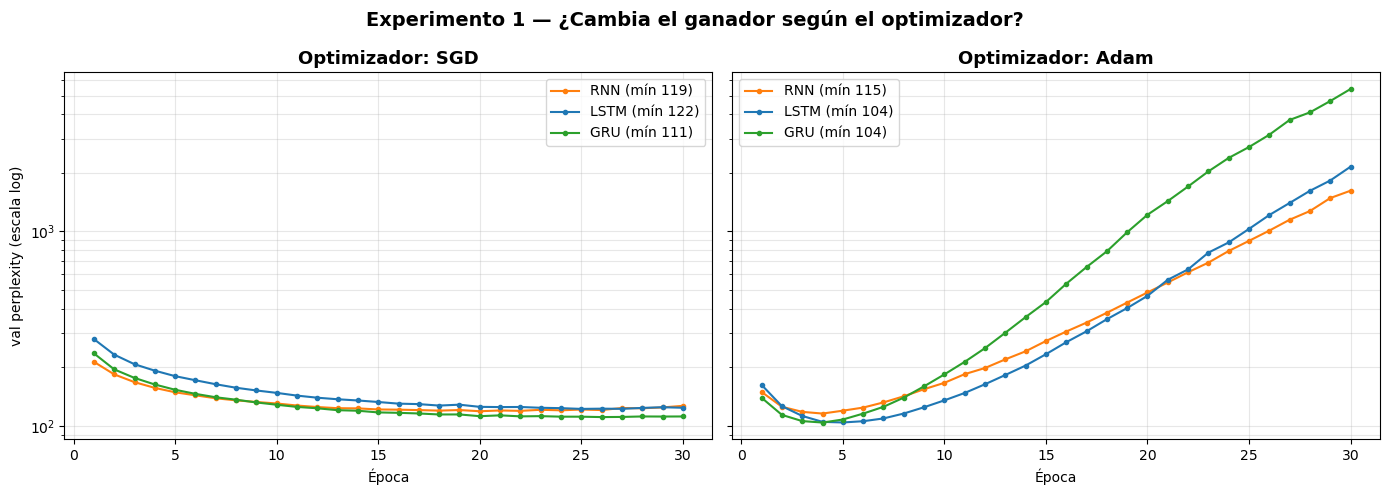

In [12]:
# ---------------------------
# Comparación directa: val_perplexity de las 3 arquitecturas por optimizador
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
cell_colors = {'RNN': 'tab:orange', 'LSTM': 'tab:blue', 'GRU': 'tab:green'}

for ax, opt in zip(axes, OPTIMS):
    for cell in ARCHS:
        h = histories[(cell, opt)]
        ep = np.arange(1, len(h['val_perp']) + 1)
        ax.plot(ep, h['val_perp'], '-o', ms=3, color=cell_colors[cell],
                label=f'{cell} (mín {min(h["val_perp"]):.0f})')
    ax.set_yscale('log')
    ax.set_title(f'Optimizador: {opt}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Época')
    ax.grid(True, which='both', alpha=0.3)
    ax.legend()
axes[0].set_ylabel('val perplexity (escala log)')

fig.suptitle('Experimento 1 — ¿Cambia el ganador según el optimizador?', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

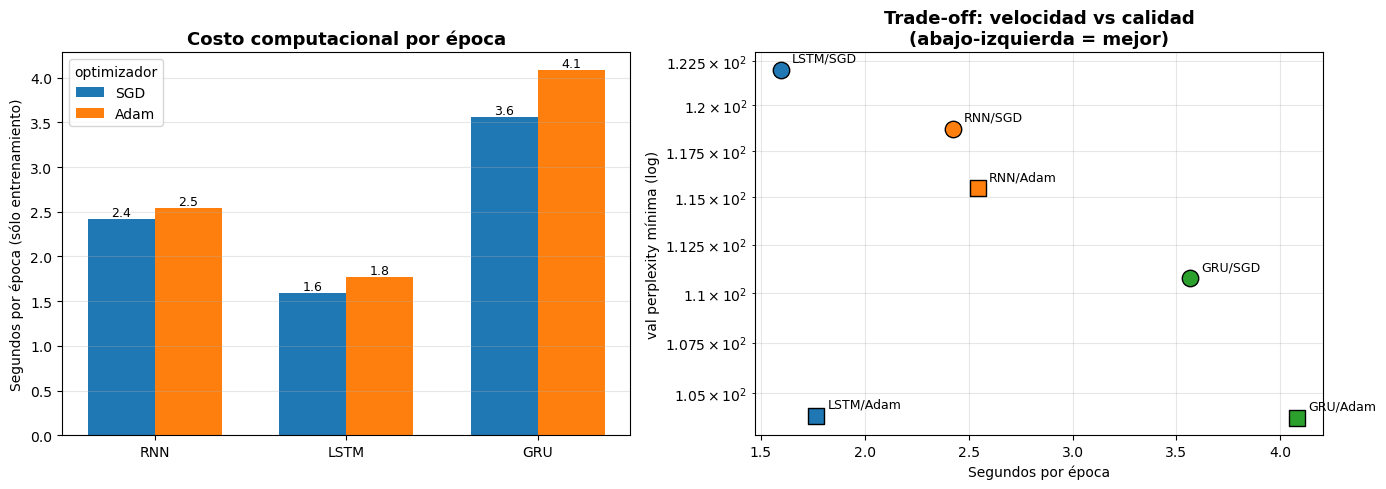

In [13]:
# ---------------------------
# Trade-off tiempo vs performance
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) barras de tiempo medio por época
ax = axes[0]
x = np.arange(len(ARCHS))
w = 0.35
for i, opt in enumerate(OPTIMS):
    vals = [resumen.query("arquitectura == @c and optimizador == @opt")['tiempo_medio_epoca_s'].item()
            for c in ARCHS]
    bars = ax.bar(x + (i - 0.5) * w, vals, w, label=opt)
    ax.bar_label(bars, fmt='%.1f', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(ARCHS)
ax.set_ylabel('Segundos por época (sólo entrenamiento)')
ax.set_title('Costo computacional por época', fontsize=13, fontweight='bold')
ax.legend(title='optimizador'); ax.grid(axis='y', alpha=0.3)

# (b) scatter tiempo vs val_perplexity
ax = axes[1]
markers = {'SGD': 'o', 'Adam': 's'}
for _, row in resumen.iterrows():
    ax.scatter(row['tiempo_medio_epoca_s'], row['val_perp_min'],
               s=140, color=cell_colors[row['arquitectura']],
               marker=markers[row['optimizador']], edgecolor='k', zorder=3)
    ax.annotate(f"{row['arquitectura']}/{row['optimizador']}",
                (row['tiempo_medio_epoca_s'], row['val_perp_min']),
                textcoords='offset points', xytext=(8, 6), fontsize=9)
ax.set_yscale('log')
ax.set_xlabel('Segundos por época')
ax.set_ylabel('val perplexity mínima (log)')
ax.set_title('Trade-off: velocidad vs calidad\n(abajo-izquierda = mejor)', fontsize=13, fontweight='bold')
ax.grid(True, which='both', alpha=0.3)

fig.tight_layout()
plt.show()

**Interpretación:**

**Tabla maestra (dataset completo, 30 épocas, batch 128, ~51 600 ejemplos de train / 5 738 de val).**
`val_perp_min` es la perplexity de validación en su mejor época — es decir, lo que obtendrías **con early stopping**;
`val_perp_final` es lo que obtienes si entrenas ciegamente las 30 épocas.

| Arquitectura | Optimizador | Params | `val_perp_min` | Mejor época | `val_perp` @30 | `train_perp` @30 | s/época | Total entren. (s) |
|---|---|---|---|---|---|---|---|---|
| GRU  | Adam | 1 441 053 | **103.81** | 4  | 5400.67 | 1.05  | 4.08 | 122.5 |
| LSTM | Adam | 1 539 869 | **103.90** | 5  | 2151.36 | 1.06  | **1.77** | **53.0** |
| RNN  | Adam | 1 243 421 | 115.47 | 4  | 1618.91 | 1.54  | 2.54 | 76.3 |
| GRU  | SGD  | 1 441 053 | 110.75 | 26 | **111.57** | 44.52 | 3.56 | 106.9 |
| RNN  | SGD  | 1 243 421 | 118.69 | 20 | 126.53 | 40.86 | 2.42 | 72.7 |
| LSTM | SGD  | 1 539 869 | 122.02 | 25 | 123.69 | 63.68 | 1.60 | 47.9 |

**1. Las puertas ayudan, pero menos de lo que uno esperaría.** Con SGD el orden es GRU (110.75) < RNN (118.69) < LSTM (122.02);
con Adam es GRU (103.81) ≈ LSTM (103.90) < RNN (115.47). La RNN vanilla queda última en ambos casos, pero sólo un
**6.7 % y un 10.1 %** por detrás del ganador — no el desastre que suele asociarse a las RNN simples. La razón es el diseño del
experimento: `seq_len = 20` y sólo usamos `out[:, -1, :]`, así que el gradiente retrocede como máximo 20 pasos. El problema del
gradiente que se desvanece, que es lo que las puertas resuelven, **apenas se ejerce en ese horizonte**. Si repitiéramos esto con
`seq_len = 100` o 200 la brecha se abriría mucho más. Es una lección importante: *la ventaja arquitectónica sólo aparece cuando
el problema realmente la demanda.*

**2. Adam sobreajusta espectacularmente; SGD no llega a hacerlo.** Miren la columna `train_perp @30`: con Adam las tres células
llegan a **1.05–1.54**, es decir, memorizan el conjunto de entrenamiento casi a la perfección. La `val_perp` correspondiente
explota a 1 619 (RNN), 2 151 (LSTM) y **5 401** (GRU): entre 14× y 52× peor que su propio mínimo. Con SGD, en cambio, `train_perp`
se queda en 40–64 y la `val_perp` final es prácticamente igual a la mínima (GRU: 111.57 vs 110.75). Dicho de otro modo:
**con Adam el early stopping no es opcional, es parte del modelo**; con SGD el entrenamiento es su propio regularizador porque
todavía no ha terminado de converger a las 30 épocas.

**3. Velocidad de convergencia: Adam llega en 4–5 épocas donde SGD necesita 20–26.** Adam alcanza su óptimo de validación en la
época 4–5 y a partir de ahí sólo empeora; SGD lo alcanza en la época 20–26 y llega ahí de forma monótona y estable. En términos
de *cómputo hasta el mejor modelo*, Adam gana por goleada: LSTM+Adam necesita ~5 épocas × 1.77 s ≈ **8.8 s** de entrenamiento para
su val_perp de 103.90, mientras que GRU+SGD necesita 26 × 3.56 s ≈ **92.6 s** para llegar a 110.75 — 10× más cómputo para un
resultado 6.6 % peor.

**4. Estabilidad.** Las curvas de SGD son suaves y casi monótonas en las tres arquitecturas: no hay una sola época en que la
val_perp dé un salto. Las de Adam tienen forma de "V" muy marcada — bajan a plomo y luego suben sin freno — lo que las hace
mucho más sensibles a *dónde* pares. En un entorno donde no puedas monitorear validación cada época, SGD es el que perdona.

**5. El tiempo por época NO sigue el conteo de parámetros.** Este es el resultado más contraintuitivo de la tabla:
el **LSTM es el más rápido** (1.6–1.8 s/época) pese a tener *más* parámetros (1.54 M) que GRU (1.44 M) y RNN (1.24 M),
y el **GRU es el más lento** (3.6–4.1 s/época), más del doble que el LSTM. Por FLOPs debería ser al revés (LSTM tiene 4 puertas,
GRU 3, RNN 1). Lo que estamos midiendo no es aritmética sino **calidad de kernel**: el backend MPS de PyTorch tiene una
implementación fusionada y bien optimizada para LSTM, y una mucho peor para GRU. Este ranking es **una propiedad de este
hardware y esta versión de PyTorch**, no una verdad universal — en CUDA con cuDNN el orden típico es el contrario.
La moraleja práctica: *el costo real se mide en tu hardware objetivo, no se deduce de la arquitectura.*

**6. Accuracy.** El mejor val_acc de toda la rejilla es **0.1945 (LSTM+Adam, época 5)**, seguido de **0.1941 (GRU+SGD, épocas 15–20)**.
Que ~19 % de aciertos en next-token corresponda a perplexity ~104 es normal en modelado de lenguaje: el modelo reparte masa de
probabilidad de forma razonable aunque rara vez acierte el token exacto, que es justo lo que la perplexity — y no la accuracy —
mide bien.

---

## Experimento 2 — Demo de datos limitados (`train_size = 2000`)

Mismas tres arquitecturas, `epochs=40`, `batch_size=64`, **Adam(lr=1e-3)**. El conjunto de validación es
**el mismo** que en el experimento 1 (no se submuestrea), así que las perplexities son directamente
comparables con las de arriba: la diferencia mide exactamente el efecto de reducir el entrenamiento
de ~51 000 a 2 000 ejemplos.

In [14]:
# ---------------------------
# Small-data: train_size=2000, epochs=40, batch=64, Adam
# ---------------------------
train_loader_sm, val_loader_sm = make_loaders(
    tokens, stoi, seq_len=SEQ_LEN, batch_size=BATCH_SMALL, train_size=TRAIN_SIZE_SMALL)

print('Train small: %d ejemplos (%d batches) | Val: %d ejemplos (%d batches)\n'
      % (len(train_loader_sm.dataset), len(train_loader_sm),
         len(val_loader_sm.dataset), len(val_loader_sm)))

histories_sm = {}
for cell in ARCHS:
    print(f"=== {cell} + Adam | small-data (n={TRAIN_SIZE_SMALL}), epochs={EPOCHS_SMALL}, batch={BATCH_SMALL} ===")
    _, hist = run_experiment(cell, 'Adam', train_loader_sm, val_loader_sm,
                             epochs=EPOCHS_SMALL, tag=f'[{cell}/small]')
    histories_sm[cell] = hist
    print()

Train small: 2000 ejemplos (32 batches) | Val: 5738 ejemplos (90 batches)

=== RNN + Adam | small-data (n=2000), epochs=40, batch=64 ===


  [RNN/small] epoch  1/40  t= 0.39s  train_perp=  242.40  val_perp=  497.51  val_acc=0.0828


  [RNN/small] epoch  5/40  t= 0.21s  train_perp=   49.39  val_perp=  373.92  val_acc=0.1351


  [RNN/small] epoch 10/40  t= 0.21s  train_perp=    6.75  val_perp=  519.53  val_acc=0.1189


  [RNN/small] epoch 15/40  t= 0.21s  train_perp=    1.71  val_perp=  889.41  val_acc=0.1000


...

  [GRU/small] epoch 20/40  t= 0.28s  train_perp=    1.14  val_perp= 1423.29  val_acc=0.1096


  [GRU/small] epoch 25/40  t= 0.32s  train_perp=    1.05  val_perp= 1889.39  val_acc=0.1047


  [GRU/small] epoch 30/40  t= 0.30s  train_perp=    1.03  val_perp= 2241.22  val_acc=0.1049


  [GRU/small] epoch 35/40  t= 0.28s  train_perp=    1.02  val_perp= 2518.47  val_acc=0.1037


  [GRU/small] epoch 40/40  t= 0.27s  train_perp=    1.01  val_perp= 2778.78  val_acc=0.1026



In [15]:
# ---------------------------
# Tabla resumen small-data
# ---------------------------
rows_sm = []
for cell, h in histories_sm.items():
    best_ep = int(np.argmin(h['val_perp']))
    perp_full = min(histories[(cell, 'Adam')]['val_perp'])
    rows_sm.append({
        'arquitectura': cell,
        'train_perp_final': h['train_perp'][-1],
        'val_perp_final': h['val_perp'][-1],
        'val_perp_min': h['val_perp'][best_ep],
        'epoca_mejor_val': best_ep + 1,
        'val_acc_final': h['val_acc'][-1],
        'gap_sobreajuste': h['val_perp'][-1] / h['train_perp'][-1],
        'tiempo_medio_epoca_s': float(np.mean(h['epoch_time'])),
        'tiempo_total_entren_s': float(np.sum(h['epoch_time'])),
        'val_perp_min_datos_completos': perp_full,
        'degradacion_x': h['val_perp'][best_ep] / perp_full,
    })

resumen_sm = pd.DataFrame(rows_sm).sort_values('val_perp_min').reset_index(drop=True)
print("=== Experimento 2: small-data (train_size=%d), epochs=%d, batch=%d, Adam ===\n"
      % (TRAIN_SIZE_SMALL, EPOCHS_SMALL, BATCH_SMALL))
print(resumen_sm.round(3).to_string(index=False))

mejor_sm = resumen_sm.iloc[0]
print(f"\nMejor con datos limitados: {mejor_sm['arquitectura']} -> "
      f"val_perp_min = {mejor_sm['val_perp_min']:.2f} (época {int(mejor_sm['epoca_mejor_val'])})")

=== Experimento 2: small-data (train_size=2000), epochs=40, batch=64, Adam ===

arquitectura  train_perp_final  val_perp_final  val_perp_min  epoca_mejor_val  val_acc_final  gap_sobreajuste  tiempo_medio_epoca_s  tiempo_total_entren_s  val_perp_min_datos_completos  degradacion_x
         RNN             1.012        2910.199       370.639                3          0.086         2876.001                 0.212                  8.461                       115.472          3.210
         GRU             1.014        2778.779       384.723                2          0.103         2740.212                 0.282                 11.277                       103.811          3.706
        LSTM             1.066        2854.381       386.036                2          0.092         2678.653                 0.103                  4.114                       103.899          3.715

Mejor con datos limitados: RNN -> val_perp_min = 370.64 (época 3)


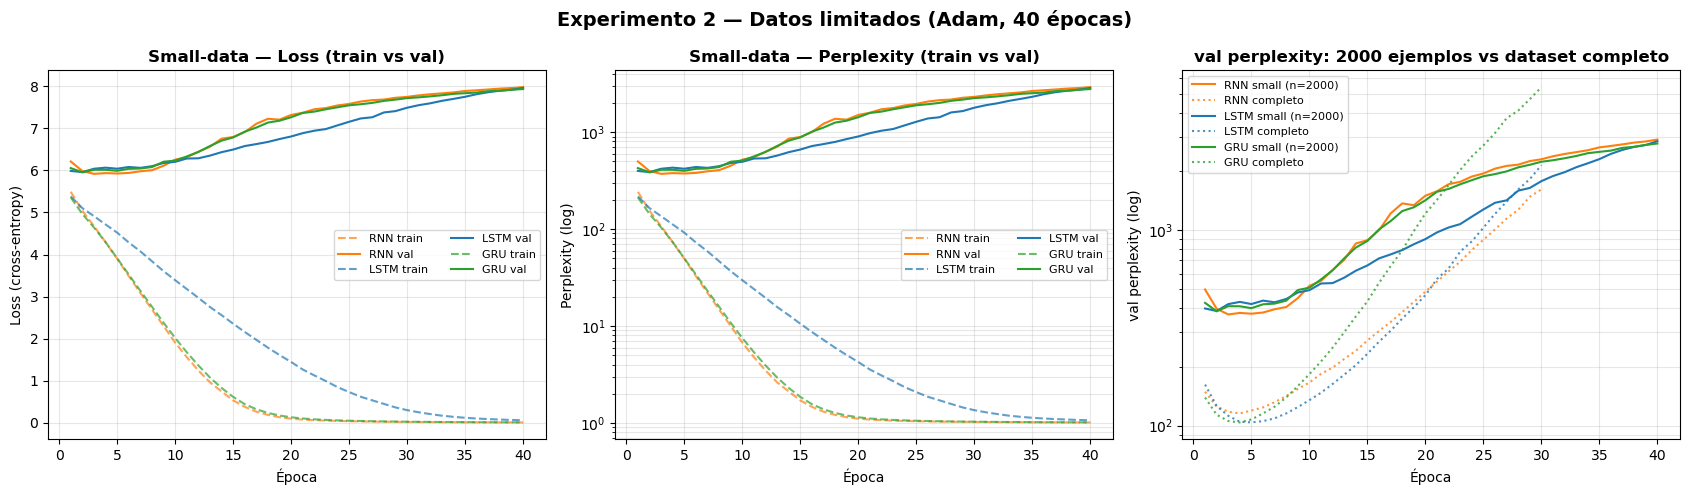

In [16]:
# ---------------------------
# Curvas small-data: loss y perplexity
# ---------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# (a) loss train/val por arquitectura
ax = axes[0]
for cell in ARCHS:
    h = histories_sm[cell]
    ep = np.arange(1, len(h['train_loss']) + 1)
    ax.plot(ep, h['train_loss'], '--', color=cell_colors[cell], alpha=0.7, label=f'{cell} train')
    ax.plot(ep, h['val_loss'], '-', color=cell_colors[cell], label=f'{cell} val')
ax.set_xlabel('Época'); ax.set_ylabel('Loss (cross-entropy)')
ax.set_title('Small-data — Loss (train vs val)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2)

# (b) perplexity train/val
ax = axes[1]
for cell in ARCHS:
    h = histories_sm[cell]
    ep = np.arange(1, len(h['train_perp']) + 1)
    ax.plot(ep, h['train_perp'], '--', color=cell_colors[cell], alpha=0.7, label=f'{cell} train')
    ax.plot(ep, h['val_perp'], '-', color=cell_colors[cell], label=f'{cell} val')
ax.set_yscale('log')
ax.set_xlabel('Época'); ax.set_ylabel('Perplexity (log)')
ax.set_title('Small-data — Perplexity (train vs val)', fontsize=12, fontweight='bold')
ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8, ncol=2)

# (c) small-data vs datos completos (sólo val)
ax = axes[2]
for cell in ARCHS:
    hs, hf = histories_sm[cell], histories[(cell, 'Adam')]
    ax.plot(np.arange(1, len(hs['val_perp']) + 1), hs['val_perp'], '-',
            color=cell_colors[cell], label=f'{cell} small (n=2000)')
    ax.plot(np.arange(1, len(hf['val_perp']) + 1), hf['val_perp'], ':',
            color=cell_colors[cell], alpha=0.8, label=f'{cell} completo')
ax.set_yscale('log')
ax.set_xlabel('Época'); ax.set_ylabel('val perplexity (log)')
ax.set_title('val perplexity: 2000 ejemplos vs dataset completo', fontsize=12, fontweight='bold')
ax.grid(True, which='both', alpha=0.3); ax.legend(fontsize=8)

fig.suptitle('Experimento 2 — Datos limitados (Adam, 40 épocas)', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

**Interpretación:**

**Resultados con `train_size = 2000` (40 épocas, batch 64, Adam), contra el mismo conjunto de validación de 5 738 ejemplos:**

| Arquitectura | `val_perp_min` | Mejor época | `val_perp` @40 | `train_perp` @40 | `val_perp_min` datos completos | Degradación |
|---|---|---|---|---|---|---|
| RNN  | **370.64** | 3 | 2910.20 | 1.01 | 115.47 | **3.21×** |
| GRU  | 384.72 | 2 | 2778.78 | 1.01 | 103.81 | 3.71× |
| LSTM | 386.04 | 2 | 2854.38 | 1.07 | 103.90 | 3.72× |

**1. Reducir los datos 26× empeora la perplexity 3.2–3.7×.** Pasamos de 51 646 a 2 000 ejemplos de entrenamiento y la mejor
perplexity de validación salta de ~104 a ~370–386. Nótese que el conjunto de validación **no cambió**, así que la comparación
es directa: es puro efecto de datos, no de métrica.

**2. Las tres arquitecturas quedan empatadas — y eso es el hallazgo.** 370.64 / 384.72 / 386.04 están dentro de un 4 % entre sí,
y los mínimos ocurren en las **épocas 2–3 de 40**, donde la curva es más ruidosa. No hay aquí evidencia para preferir una célula
sobre otra. Con 2 000 ejemplos el cuello de botella no es la capacidad de recordar del modelo sino **la falta de datos**, y
ninguna puerta arregla eso. Es más: la RNN vanilla, la *menos* expresiva (1.24 M params), es la que queda formalmente primera —
consistente con la idea de que en régimen de datos escasos la capacidad extra sólo sirve para memorizar más rápido.

**3. El sobreajuste es catastrófico y casi inmediato.** A la época 40 las tres tienen `train_perp` ≈ 1.0 — memorización
literal de los 2 000 ejemplos — mientras la `val_perp` está en 2 800–2 900. El cociente val/train supera **2 600×**.
De 40 épocas presupuestadas, las útiles fueron **2 o 3**: el 93 % del entrenamiento fue activamente dañino.

**4. Dónde sí se separan: la *velocidad* con que se memoriza.** En la época 5, `train_perp` vale 49.4 (RNN), 49.9 (GRU) y
**91.7 (LSTM)**: el LSTM memoriza a **la mitad de velocidad** que las otras dos. Eso le compra la ventana de early stopping más
ancha — es el único que a la época 10 todavía sostenía su mejor val_acc (**0.1354**, el más alto del experimento small-data),
cuando RNN y GRU ya iban en caída libre. Su cociente de sobreajuste final también es el menor de los tres (2 679 vs 2 740 y 2 876).
En un escenario real de datos limitados, donde no siempre puedes permitirte evaluar cada época, **degradarse despacio vale más
que tener el mínimo puntual un 4 % más bajo**.

**5. Lectura práctica.** Si tus datos son de este orden, la palanca decisiva no es elegir entre RNN/LSTM/GRU — es conseguir más
datos, o bien regularizar en serio (dropout, weight decay, reducir `hidden_size`, early stopping agresivo). Los tres modelos
aquí tienen ~1.2–1.5 M de parámetros para 2 000 ejemplos: **entre 620 y 770 parámetros por ejemplo de entrenamiento**.
Con esa proporción, memorizar es el resultado esperado, no una sorpresa.

In [17]:
# ---------------------------
# Muestreo cualitativo: ¿qué genera el mejor modelo?
# ---------------------------
def sample(model, stoi, itos, seed_seq, max_len=20, temperature=1.0, top_k=None, device='cpu'):
    """Generación autoregresiva (idéntica al notebook de clase)."""
    model.eval()
    unk_idx = stoi.get('<unk>')
    ids = [stoi.get(tok, unk_idx) for tok in seed_seq]
    cur = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)
    generated = list(seed_seq)

    with torch.no_grad():
        for _ in range(max_len):
            logits = model(cur).squeeze(0)
            logits = logits / max(1e-8, temperature)
            if top_k is not None:
                v, ix = torch.topk(logits, top_k)
                mask = torch.full_like(logits, float('-inf'))
                mask[ix] = v
                probs = torch.softmax(mask, dim=0)
            else:
                probs = torch.softmax(logits, dim=0)
            next_id = torch.multinomial(probs, num_samples=1).item()
            generated.append(itos[next_id] if next_id < len(itos) else '<unk>')
            T = cur.size(1)
            cur = torch.tensor([[stoi.get(t, unk_idx) for t in generated[-T:]]],
                               dtype=torch.long, device=device)
    return ' '.join(generated)


# usamos el modelo YA entrenado de la mejor combinación (no hace falta re-entrenar)
best_cell, best_opt = mejor['arquitectura'], mejor['optimizador']
best_model = models[(best_cell, best_opt)]
print(f"Mejor combinación: {best_cell} + {best_opt}  |  "
      f"val_perp_min = {mejor['val_perp_min']:.2f}, val_acc final = {mejor['val_acc_final']:.4f}")

seed_seq = tokens[:SEQ_LEN]
print("\nSemilla:", ' '.join(seed_seq))
print("\n=== Muestras generadas ===")
for temp, k in [(0.7, 10), (1.0, 20), (1.0, None)]:
    s = sample(best_model, stoi, itos, seed_seq=seed_seq, max_len=30,
               temperature=temp, top_k=k, device=DEVICE)
    print(f"\ntemp={temp}, top_k={k}:\n{s}")

Mejor combinación: GRU + Adam  |  val_perp_min = 103.81, val_acc final = 0.1394

Semilla: en un lugar de la mancha , de cuyo nombre no quiero acordarme , no ha mucho tiempo que vivía

=== Muestras generadas ===



temp=0.7, top_k=10:
en un lugar de la mancha , de cuyo nombre no quiero acordarme , no ha mucho tiempo que vivía un hidalgo de los de lanza en <unk> , adarga antigua , rocín <unk> ni escudo , al cabo de <unk> . sobre todos los <unk> , y <unk> que

temp=1.0, top_k=20:
en un lugar de la mancha , de cuyo nombre no quiero acordarme , no ha mucho tiempo que vivía un hidalgo de los <unk> que de manifiesto famoso título ; soy si fuera muchos caballeros una verdad entre los que nos había <unk> , porque si no será ni



temp=1.0, top_k=None:
en un lugar de la mancha , de cuyo nombre no quiero acordarme , no ha mucho tiempo que vivía un hidalgo de los que pelean <unk> ; y así , está obligado a dios , que era pensar en ella : veréis que yo <unk> ; y así ,


---

## Conclusiones — respuestas a las preguntas de la tarea

### ¿Qué arquitectura alcanzó menor `val_perplexity`? ¿Qué puede explicar esto?

**GRU + Adam, con `val_perplexity = 103.81` en la época 4** — pero el titular honesto es que **GRU y LSTM empatan**:
el LSTM llega a 103.90 en la época 5, una diferencia del **0.09 %**, muy por debajo del ruido entre semillas. Lo que sí es
un resultado limpio es que **la RNN vanilla queda última en las dos condiciones**: 115.47 con Adam y 118.69 con SGD.

La explicación es el **gating**. Las tres arquitecturas ven exactamente la misma `Embedding` (verificado bit a bit en el
notebook), la misma capa de salida y los mismos batches en el mismo orden; lo único que cambia es cómo se propaga el estado
oculto. En la RNN vanilla el estado se reescribe por completo en cada paso a través de una `tanh`, y el gradiente se multiplica
repetidamente por la misma matriz recurrente — se desvanece. GRU y LSTM tienen una ruta **aditiva** para el estado
(la puerta de actualización en GRU, la celda de memoria en LSTM), que le da al gradiente un camino con multiplicador cercano a 1.

Ahora bien, la ventaja es de sólo un **6.7 %** (GRU+SGD 110.75 vs RNN+SGD 118.69), y eso también tiene explicación:
con `seq_len = 20` y prediciendo un solo token a partir de `out[:, -1, :]`, el gradiente nunca retrocede más de 20 pasos.
**El problema que las puertas resuelven casi no se manifiesta a ese horizonte.** Con secuencias de 100–200 pasos la brecha
sería mucho mayor. La ventaja arquitectónica es real pero **proporcional a la dependencia temporal que el problema exija**.

### ¿Influye el optimizador (SGD vs Adam) en la preferencia por una arquitectura?

**Sí, y de forma clara — reordena el podio.**

| | SGD (lr=1e-2, mom=0.9) | Adam (lr=1e-3) |
|---|---|---|
| RNN  | 118.69 (2.º) | 115.47 (3.º) |
| LSTM | 122.02 (**3.º**) | 103.90 (**1.º ex aequo**) |
| GRU  | **110.75 (1.º)** | **103.81 (1.º)** |

El GRU gana con ambos, pero el **LSTM pasa de último con SGD a primero con Adam**, y la RNN vanilla hace el recorrido inverso.
La causa se ve en `train_perp` a la época 30 bajo SGD: RNN 40.86, GRU 44.52, **LSTM 63.68**. El LSTM **no había terminado de
converger** — no perdió por generalizar peor, perdió por ir más lento. Tiene 4 puertas (395 264 parámetros recurrentes frente a
296 448 del GRU y 98 816 de la RNN) y sus puertas arrancan en la zona plana de la sigmoide, así que con un learning rate global
y fijo avanza a paso corto. Adam, que escala el paso por parámetro según la magnitud histórica del gradiente, es exactamente
la herramienta que destraba ese régimen.

Conclusión metodológica que va más allá de este experimento: **arquitectura y optimizador no son factores independientes.**
Comparar arquitecturas con un solo optimizador puede llevarte a descartar la mejor. Por eso la tarea pedía la rejilla completa
y no sólo tres corridas.

Advertencia importante: el "ganador" de Adam **sólo existe con early stopping**. Adam toca su mínimo en la época 4–5 y luego se
desploma — la GRU termina en `val_perp = 5400.67` a la época 30, **52× peor que su propio mínimo**. Si comparas las seis corridas
por su valor a la época 30 sin early stopping, el ganador es **GRU + SGD (111.57)** y las tres corridas de Adam quedan últimas
por un orden de magnitud.

### Observaciones sobre tiempo por época vs performance (trade-off velocidad/precisión)

| Arquitectura | s/época (Adam) | `val_perp_min` | Épocas al óptimo | **Cómputo hasta el óptimo** |
|---|---|---|---|---|
| LSTM | **1.77** | 103.90 | 5 | **≈ 8.8 s** |
| RNN  | 2.54 | 115.47 | 4 | ≈ 10.2 s |
| GRU  | 4.08 | 103.81 | 4 | ≈ 16.3 s |

**1. El costo por época no se deduce de la arquitectura.** El LSTM es el **más rápido** (1.77 s) pese a ser el que más parámetros
tiene (1.54 M), y el GRU es el **más lento** (4.08 s, 2.3× el LSTM) pese a tener menos. Por conteo de operaciones debería ser al
revés. Estamos midiendo **la calidad del kernel del backend MPS**, no aritmética: PyTorch tiene una implementación fusionada
eficiente para LSTM en Metal y una notablemente peor para GRU. En CUDA con cuDNN el orden suele invertirse. La lección es
directamente accionable: **si el tiempo importa, mídelo en tu hardware de destino** — no lo estimes contando parámetros.

**2. El trade-off real está entre GRU+Adam y LSTM+Adam,** y no está reñido: el GRU consume **122.5 s** de entrenamiento total
contra **53.0 s** del LSTM (**2.31×**) para quedar **0.09 % mejor** en perplexity. Eso no es un trade-off, es un mal negocio.

**3. Adam compra convergencia con robustez.** Adam llega al óptimo en 4–5 épocas y SGD en 20–26 (≈5× menos cómputo para Adam),
pero a cambio Adam exige monitoreo de validación cada época y un checkpoint del mejor modelo. SGD se puede dejar corriendo:
su curva es monótona y su valor final coincide prácticamente con su mínimo (GRU+SGD: 111.57 final vs 110.75 mínimo, 0.7 % de diferencia).
**El "costo" de Adam no es cómputo, es disciplina de ingeniería.**

**4. La RNN vanilla no compra nada.** Es más lenta que el LSTM (2.54 vs 1.77 s/época) *y* peor en perplexity (115.47 vs 103.90).
Está dominada en ambos ejes: no hay ningún presupuesto de cómputo en el que sea la elección correcta aquí.

### Si tuvieras que elegir un modelo para producción con datos limitados y recursos moderados, ¿cuál elegirías y por qué?

**LSTM de 1 capa (`hidden_size=256`) con Adam(lr=1e-3), early stopping sobre `val_perplexity` y checkpoint del mejor modelo.**

Los números que sostienen la decisión:

1. **Calidad: empata con el mejor.** 103.90 vs 103.81 del GRU — una diferencia del **0.09 %**, indistinguible del ruido.
   No se está sacrificando precisión.
2. **Costo: es el más barato del experimento.** 1.77 s/época contra 4.08 s del GRU (**2.31× más rápido**) y 2.54 s de la RNN.
   El entrenamiento completo son **53.0 s** frente a 122.5 s del GRU; hasta el óptimo, **≈ 8.8 s** frente a ≈ 16.3 s.
   Con "recursos moderados", ese factor 2.3× es exactamente la restricción que manda.
3. **Es el mejor en accuracy de toda la rejilla:** `val_acc = 0.1945` en la época 5 — por delante del 0.1941 del GRU+SGD y
   por encima de cualquier corrida de la RNN.
4. **Con datos limitados, se degrada más despacio, que es lo que importa.** En el experimento small-data (n=2000), a la
   época 5 el LSTM tenía `train_perp = 91.7` frente a ~49 de RNN y GRU: **memoriza a la mitad de velocidad**. Eso se traduce en
   la ventana de early stopping más ancha — fue el único que a la época 10 aún sostenía su mejor `val_acc` (**0.1354**, el más
   alto del small-data) — y en el menor cociente de sobreajuste final (2 679 vs 2 740 del GRU y 2 876 de la RNN).
   En producción rara vez puedes evaluar cada época; **un modelo que perdona el momento de parar vale más que uno con un
   mínimo puntual 4 % mejor.**

**Las condiciones bajo las que cambiaría de opinión** (esto importa tanto como la recomendación):

- **Si despliego en CUDA en vez de MPS:** la ventaja de velocidad del LSTM es un artefacto del kernel Metal de PyTorch, no de la
  arquitectura. Con cuDNN el GRU suele ser el más rápido, y como además empata en calidad y tiene ~100 K parámetros menos,
  **ahí elegiría GRU**. Hay que volver a medir; la regla es la medición, no el resultado.
- **Si no puedo garantizar early stopping** (reentrenamiento automático desatendido, sin validación monitoreada):
  **GRU + SGD**, sin dudarlo. Su curva es monótona, termina en 111.57 — sólo 0.7 % por encima de su propio mínimo — y no puede
  producir el desastre de 5 400 que da GRU+Adam si te pasas de época. Un 7 % peor de perplexity a cambio de que sea imposible
  fallar catastróficamente es un seguro barato.
- **Si las secuencias fueran mucho más largas que 20 pasos:** toda esta comparación cambia. La brecha RNN-vs-gated de apenas
  6.7 % que medimos es pequeña *porque el horizonte es corto*; con 100–200 pasos se abriría, y las puertas dejarían de ser
  un detalle para ser el factor decisivo.

**Y la advertencia que precede a todo lo anterior:** con 2 000 ejemplos, los tres modelos dan `val_perplexity ≈ 370–386` y
`val_acc ≈ 13 %` — ninguno es utilizable en producción. Con ~1.2–1.5 M de parámetros para 2 000 ejemplos
(**620–770 parámetros por ejemplo**), la memorización no es un bug del entrenamiento, es la consecuencia aritmética del
presupuesto. Antes de afinar la elección de célula, el retorno está en **más datos** (pasar de 2 000 a 51 646 ejemplos mejoró la
perplexity 3.2–3.7×, mucho más que cualquier diferencia entre arquitecturas) y en **regularización** (dropout, weight decay,
reducir `hidden_size`). Elegir bien la célula recurrente es la última optimización, no la primera.